# Project Capstone

## Import Libraries

In [41]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import numpy as np

## Data Wrangling

In [42]:
data = pd.read_csv("./data/data.csv")
data = pd.DataFrame(data)
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [44]:
data.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [45]:
data.fillna(value="None", inplace=True)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [47]:
print("Jumlah duplikasi: ", data.duplicated().sum())

Jumlah duplikasi:  0


In [48]:
dataset = data.drop(columns=['Person ID', 'Occupation', 'Blood Pressure'])
dataset.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,6.1,6,42,6,Overweight,77,4200,None
1,Male,28,6.2,6,60,8,Normal,75,10000,None
2,Male,28,6.2,6,60,8,Normal,75,10000,None
3,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea
4,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea


In [49]:
dataset.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


## Fitur Rekomendasi (Clustering)

In [50]:
x_cluster = ['Quality of Sleep', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Daily Steps']
data_selected = dataset[x_cluster]

label_encoders = {}
for column in data_selected.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    data_selected[column] = label_encoders[column].fit_transform(data_selected[column])

In [51]:
scaler = StandardScaler()

In [52]:
clusters_result = {}

for feature in x_cluster:
    feature_data = data_selected[[feature]].values
    
    feature_scaled = scaler.fit_transform(feature_data)
    
    if feature == 'Quality of Sleep':
        n_clusters = 3
    else:
        n_clusters = 2
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(feature_scaled)
    
    cluster_centers = np.sort(kmeans.cluster_centers_.flatten())
    
    if feature == 'Stress Level':
        cluster_labels = {cluster: 'Baik' if center < 0 else 'Buruk'
                          for cluster, center in enumerate(cluster_centers)}
    elif feature == 'Quality of Sleep':
        cluster_labels = {0: 'Baik', 1: 'Cukup', 2: 'Buruk'}
    else:
        cluster_labels = {cluster: 'Baik' if center > 0 else 'Buruk'
                          for cluster, center in enumerate(cluster_centers)}
    
    labeled_clusters = [cluster_labels[cluster] for cluster in clusters]
    
    clusters_result[feature] = labeled_clusters

In [53]:
for feature, labels in clusters_result.items():
    dataset[f"{feature} Cluster"] = labels

dataset

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Quality of Sleep Cluster,Sleep Duration Cluster,Physical Activity Level Cluster,Stress Level Cluster,Daily Steps Cluster
0,Male,27,6.1,6,42,6,Overweight,77,4200,None,Cukup,Buruk,Buruk,Buruk,Baik
1,Male,28,6.2,6,60,8,Normal,75,10000,None,Cukup,Buruk,Buruk,Buruk,Buruk
2,Male,28,6.2,6,60,8,Normal,75,10000,None,Cukup,Buruk,Buruk,Buruk,Buruk
3,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea,Cukup,Buruk,Buruk,Buruk,Baik
4,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea,Cukup,Buruk,Buruk,Buruk,Baik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,Baik,Baik,Baik,Baik,Buruk
370,Female,59,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,Baik,Baik,Baik,Baik,Buruk
371,Female,59,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,Baik,Baik,Baik,Baik,Buruk
372,Female,59,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,Baik,Baik,Baik,Baik,Buruk


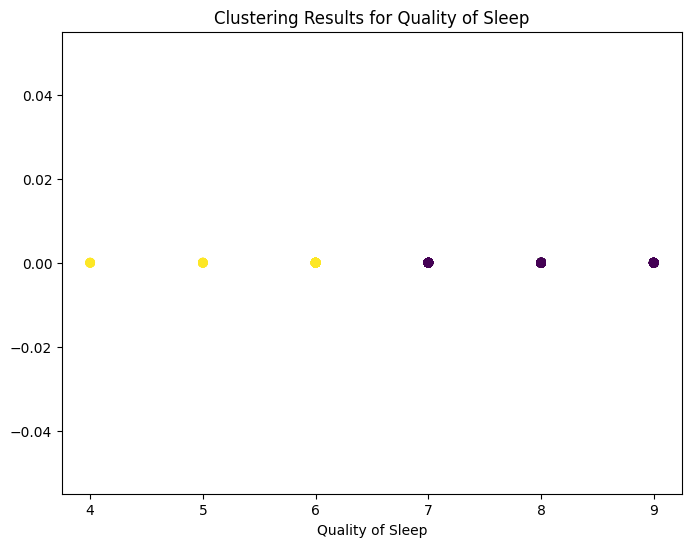

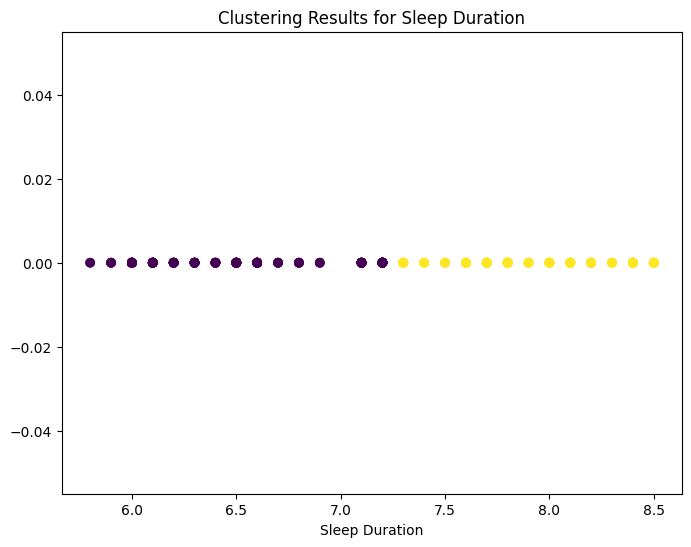

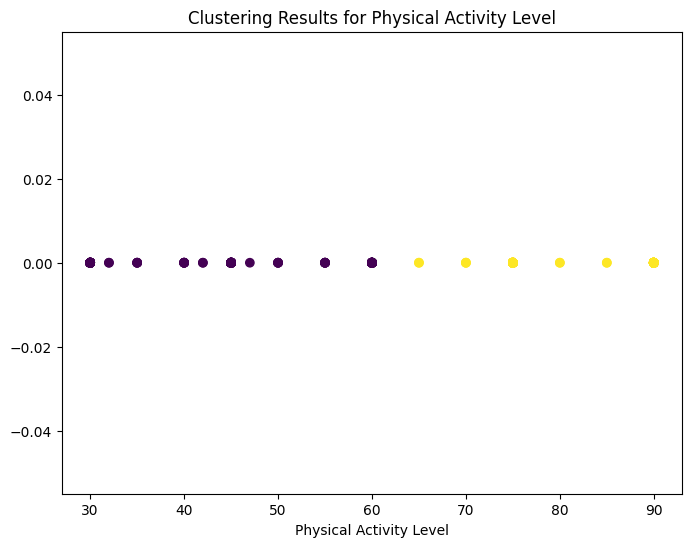

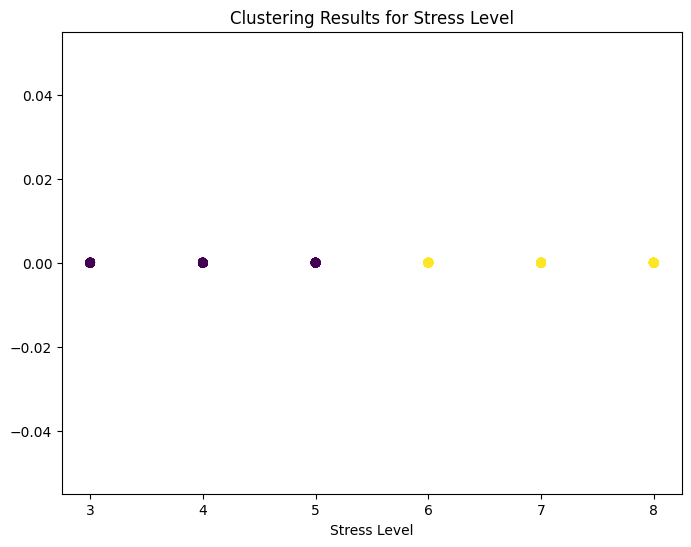

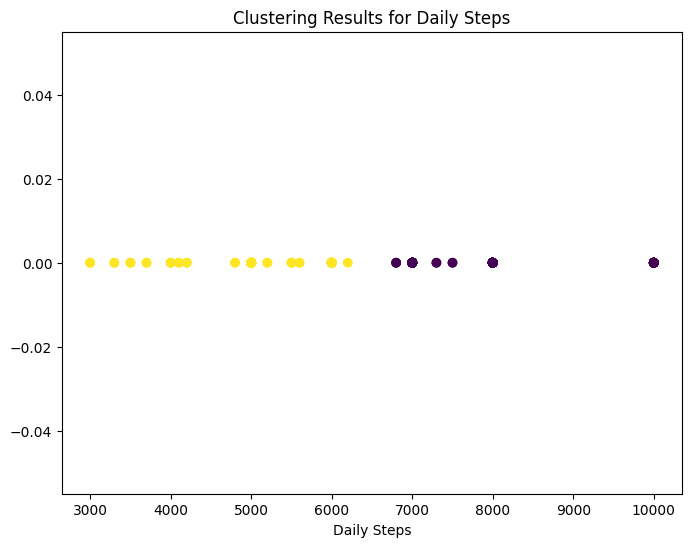

In [54]:
for feature in x_cluster:
    feature_data = data_selected[[feature]].values
    feature_scaled = scaler.fit_transform(feature_data)
    
    kmeans = KMeans(n_clusters=2, random_state=42)
    clusters = kmeans.fit_predict(feature_scaled)

    plt.figure(figsize=(8, 6))
    plt.scatter(feature_data, [0] * len(feature_data), c=clusters, cmap='viridis')
    plt.xlabel(feature)
    plt.title(f"Clustering Results for {feature}")
    plt.show()

## Fitur Rekomendasi

In [55]:
def generate_recommendation(row):
    recommendations = []
    if row['Sleep Duration Cluster'] == 'Buruk':
        recommendations.append("Tingkatkan durasi tidur Anda.")
    if row['Physical Activity Level Cluster'] == 'Buruk':
        recommendations.append("Tingkatkan aktivitas fisik.")
    if row['Stress Level Cluster'] == 'Buruk':
        recommendations.append("Kurangi tingkat stres Anda.")
    if row['Daily Steps Cluster'] == 'Buruk':
        recommendations.append("Tambahkan langkah harian Anda.")
    return " | ".join(recommendations) if recommendations else "Semua sudah baik, pertahankan kebiasaan!"

dataset['Recommendation'] = dataset.apply(generate_recommendation, axis=1)

In [56]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Gender                           374 non-null    object 
 1   Age                              374 non-null    int64  
 2   Sleep Duration                   374 non-null    float64
 3   Quality of Sleep                 374 non-null    int64  
 4   Physical Activity Level          374 non-null    int64  
 5   Stress Level                     374 non-null    int64  
 6   BMI Category                     374 non-null    object 
 7   Heart Rate                       374 non-null    int64  
 8   Daily Steps                      374 non-null    int64  
 9   Sleep Disorder                   374 non-null    object 
 10  Quality of Sleep Cluster         374 non-null    object 
 11  Sleep Duration Cluster           374 non-null    object 
 12  Physical Activity Leve

## Data Encoding

In [57]:
label_encoders = {}
for column in dataset.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    dataset[column] = label_encoders[column].fit_transform(dataset[column])

In [58]:
dataset.describe()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Quality of Sleep Cluster,Sleep Duration Cluster,Physical Activity Level Cluster,Stress Level Cluster,Daily Steps Cluster,Recommendation
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,0.505348,42.184492,7.132086,7.312834,59.171123,5.385027,1.296791,70.165775,6816.844920,1.002674,0.831551,0.561497,0.617647,0.443850,0.561497,5.826203
std,0.500641,8.673133,0.795657,1.196956,20.830804,1.774526,1.431226,4.135676,1617.915679,0.644626,0.876239,0.496868,0.486613,0.497503,0.496868,2.827338
min,0.000000,27.000000,5.800000,4.000000,30.000000,3.000000,0.000000,65.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,35.250000,6.400000,6.000000,45.000000,4.000000,0.000000,68.000000,5600.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,1.000000,43.000000,7.200000,7.000000,60.000000,5.000000,0.000000,70.000000,7000.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,6.000000
75%,1.000000,50.000000,7.800000,8.000000,75.000000,7.000000,3.000000,72.000000,8000.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,8.000000
max,1.000000,59.000000,8.500000,9.000000,90.000000,8.000000,3.000000,86.000000,10000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,10.000000


In [59]:
dataset.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Quality of Sleep Cluster,Sleep Duration Cluster,Physical Activity Level Cluster,Stress Level Cluster,Daily Steps Cluster,Recommendation
0,1,27,6.1,6,42,6,3,77,4200,1,2,1,1,1,0,8
1,1,28,6.2,6,60,8,0,75,10000,1,2,1,1,1,1,9
2,1,28,6.2,6,60,8,0,75,10000,1,2,1,1,1,1,9
3,1,28,5.9,4,30,8,2,85,3000,2,2,1,1,1,0,8
4,1,28,5.9,4,30,8,2,85,3000,2,2,1,1,1,0,8


## Split Data

In [60]:
x = dataset.drop(columns=['Quality of Sleep', 'Quality of Sleep Cluster', 'Sleep Duration Cluster', 'Physical Activity Level Cluster', 'Stress Level Cluster', 'Daily Steps Cluster', 'Recommendation'])
y = dataset[['Quality of Sleep', 'Quality of Sleep Cluster', 'Sleep Duration Cluster', 'Physical Activity Level Cluster', 'Stress Level Cluster', 'Daily Steps Cluster', 'Recommendation']]

In [61]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=42)

print("Training data size:", len(x_train))
print("Validation data size:", len(x_val))

print("\nTraining label size:", len(y_train))
print("Validation label size:", len(y_val))

Training data size: 261
Validation data size: 113

Training label size: 261
Validation label size: 113


In [92]:
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_val_scaled = pd.DataFrame(x_val_scaled, columns=x_val.columns)

x_train_scaled.max()
x_val_scaled.max()

Gender                     1.043072
Age                        1.979656
Sleep Duration             1.741794
Physical Activity Level    1.422377
Stress Level               1.521254
BMI Category               1.187638
Heart Rate                 3.599302
Daily Steps                1.923039
Sleep Disorder             1.596433
dtype: float64

## Machine Learning

In [ ]:
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs['val_mae'] <= 0.05 and epoch >= 250:
            print("Early stopping triggered at epoch ", epoch, " because validation MAE is less than 0.1")
            self.model.stop_training = True

In [ ]:
embedding_dim = 4

model = tf.keras.Sequential([
  tf.keras.Input(shape=(x_train.shape[1],)),  # Specify input shape
  tf.keras.layers.Embedding(input_dim=dataset['Gender'].nunique(), output_dim=embedding_dim),
  tf.keras.layers.Embedding(input_dim=dataset['Sleep Disorder'].nunique(), output_dim=embedding_dim),
  tf.keras.layers.Embedding(input_dim=dataset['Quality of Sleep'].nunique(), output_dim=embedding_dim),
  tf.keras.layers.Embedding(input_dim=dataset['Sleep Duration Cluster'].nunique(), output_dim=embedding_dim),
  tf.keras.layers.Embedding(input_dim=dataset['Physical Activity Level Cluster'].nunique(), output_dim=embedding_dim),
  tf.keras.layers.Embedding(input_dim=dataset['Stress Level Cluster'].nunique(), output_dim=embedding_dim),
  tf.keras.layers.Embedding(input_dim=dataset['Daily Steps Cluster'].nunique(), output_dim=embedding_dim),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(32, activation='relu'),
  # Ensure final layer has same number of units as unique classes in y_train
  tf.keras.layers.Dense(7, activation='softmax')
])

In [94]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_56 (Embedding)        │ (None, 9, 4)           │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_57 (Embedding)        │ (None, 9, 4, 4)        │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_58 (Embedding)        │ (None, 9, 4, 4, 4)     │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_59 (Embedding)        │ (None, 9, 4, 4, 4, 4)  │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_60 (Embedding)        │ (None, 9, 4, 4, 4, 4,  │             8 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_61 (Embedding)        │ (None, 9, 4, 4, 4, 4,  │             8 │
│                                 │ 4, 4)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_62 (Embedding)        │ (None, 9, 4, 4, 4, 4,  │             8 │
│                                 │ 4, 4, 4)               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │     9,437,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,439,647 (36.01 MB)

 Trainable params: 9,439,647 (36.01 MB)

 Non-trainable params: 0 (0.00 B)

In [95]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [96]:
# Train the model
history = model.fit(
    x_train_scaled,
    y_train,
    validation_data=(x_train_scaled, y_val),
    epochs=50,
    batch_size=16
)

Epoch 1/50


c:\Program Files\Python312\Lib\site-packages\keras\src\optimizers\base_optimizer.py:731: UserWarning: Gradients do not exist for variables ['embeddings', 'embeddings', 'embeddings', 'embeddings', 'embeddings', 'embeddings'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


InvalidArgumentError: Graph execution error:

Detected at node sequential_8_1/embedding_56_1/GatherV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\adidy\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\adidy\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\adidy\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "C:\Users\adidy\AppData\Roaming\Python\Python312\site-packages\tornado\platform\asyncio.py", line 205, in start

  File "c:\Program Files\Python312\Lib\asyncio\base_events.py", line 641, in run_forever

  File "c:\Program Files\Python312\Lib\asyncio\base_events.py", line 1987, in _run_once

  File "c:\Program Files\Python312\Lib\asyncio\events.py", line 88, in _run

  File "C:\Us

In [89]:
for col in ['Gender', 'Sleep Disorder', 'Quality of Sleep', 'Sleep Duration Cluster', 'Physical Activity Level Cluster', 'Stress Level Cluster', 'Daily Steps Cluster']:
    print(f"{col}: Unique values = {dataset[col].nunique()}, Max value = {dataset[col].max()}")

Gender: Unique values = 2, Max value = 1
Sleep Disorder: Unique values = 3, Max value = 2
Quality of Sleep: Unique values = 6, Max value = 9
Sleep Duration Cluster: Unique values = 2, Max value = 1
Physical Activity Level Cluster: Unique values = 2, Max value = 1
Stress Level Cluster: Unique values = 2, Max value = 1
Daily Steps Cluster: Unique values = 2, Max value = 1


In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']

# Create a range for epochs
epochs = range(1, len(loss) + 1)

# Plot the loss over epochs
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE plot
plt.subplot(1, 2, 2)
plt.plot(epochs, mae, label='Training MAE')
plt.plot(epochs, val_mae, label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.show()

In [ ]:
predictions = model.predict(x_val_scaled)

print("Beberapa prediksi:")
for i in range(1):
    for j in range(y_train.shape[1]):
        feature_name = y_val.columns[j]
        rounded_pred = round(predictions[i][j])
        if feature_name in label_encoders:
            pred_original = label_encoders[feature_name].inverse_transform([rounded_pred])[0]
            actual_original = label_encoders[feature_name].inverse_transform([y_val.iloc[i, j]])[0]
        else:
            pred_original = predictions[i][j]
            actual_original = y_val.iloc[i, j]
        try:
            pred_original = float(pred_original)
            actual_original = float(actual_original)
            print(f"Prediksi untuk target {feature_name}: {round(pred_original):.2f}, Nilai aktual: {actual_original:.2f}")
        except ValueError:
            print(f"Prediksi untuk target {feature_name}: {pred_original}, Nilai aktual: {actual_original}")
    print()

In [ ]:
# Output dari model klasifikasi sebelumnya untuk fitur-fitur yang relevan
output_model = {
    'Sleep Duration': 'Baik',       # Bisa juga 'Buruk'
    'Physical Activity': 'Buruk',   # Bisa juga 'Baik'
    'Stress Level': 'Baik',         # Bisa juga 'Buruk'
    'Daily Steps': 'Baik'           # Bisa juga 'Buruk'
}

# Definisikan rekomendasi berdasarkan kondisi fitur
recommendations = {
    'Baik': "Anda sudah berada pada jalur yang baik. Pertahankan gaya hidup sehat!",
    'Buruk': "Ada beberapa area yang perlu perbaikan. Berikut adalah rekomendasi untuk Anda:"
}

# Rekomendasi spesifik berdasarkan fitur
specific_recommendations = {
    'Sleep Duration': "Tidur lebih awal dan cukup untuk meningkatkan kualitas tidur Anda.",
    'Physical Activity': "Cobalah untuk lebih aktif bergerak, seperti berolahraga ringan setiap hari.",
    'Stress Level': "Mengurangi stres dapat dilakukan dengan teknik relaksasi seperti meditasi.",
    'Daily Steps': "Tingkatkan jumlah langkah harian Anda untuk kesehatan yang lebih baik."
}

# Fungsi untuk menghasilkan rekomendasi berdasarkan output model
def generate_recommendation(output_model):
    # Cek apakah ada yang 'Buruk'
    bad_clusters = [feature for feature, cluster in output_model.items() if cluster == 'Buruk']
    
    # Jika semua baik
    if len(bad_clusters) == 0:
        return recommendations['Baik']
    
    # Jika ada cluster yang buruk, buat rekomendasi berdasarkan cluster buruk tersebut
    recommendation_text = recommendations['Buruk'] + "\n"
    for feature in bad_clusters:
        recommendation_text += f"- {specific_recommendations[feature]}\n"
    
    return recommendation_text

# Hasil rekomendasi berdasarkan output model
recommendation = generate_recommendation(output_model)
print(recommendation)

## Save Model

In [ ]:
model.save('model_klasifikasi.h5')

## Load Model

In [ ]:
loaded_model_klasifikasi = tf.keras.models.load_model('model_klasifikasi.h5')

In [ ]:
loaded_model_klasifikasi.summary()

In [ ]:
predictions = loaded_model_klasifikasi.predict(x_val_scaled)

print("Beberapa prediksi pertama:")
for i in range(4):
    for j in range(y_train.shape[1]):
        print(f"Prediksi untuk target {y_val.columns[j]}: {predictions[i][j]:.2f}, Nilai aktual: {y_val.iloc[i, j]:.2f}")
    print()

## User Input (Error)

In [ ]:
gender = input("Gender (Male/Female): ")
age = int(input("Age: "))
sleep_duration = float(input("Sleep Duration (Per hours): "))
physical_activity_level = int(input("Physical Activity Level (Per minutes): "))
stress_level = int(input("Stress Level (scale 1-10): "))
bmi_category = input("BMI Category (Normal Weight, Normal, Overweight, Obese): ")
heart_rate = int(input("Heart Rate (BPM): "))
daily_steps = int(input("Daily Steps: "))
sleep_disorder = input("Sleep Disorder (None, Sleep Apnea, Insomnia): ")

In [ ]:
data_input = {
    "Gender": gender,
    "Age": age,
    "Sleep Duration": sleep_duration,
    "Physical Activity Level": physical_activity_level,
    "Stress Level": stress_level,
    "BMI Category": bmi_category,
    "Heart Rate": heart_rate,
    "Daily Steps": daily_steps, 
    "Sleep Disorder": sleep_disorder
}

data_user = pd.DataFrame([data_input])
dataset = pd.concat([dataset, data_user], ignore_index=True)

In [ ]:
# Data Encoding
for column in data_user.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    data_user[column] = label_encoders[column].fit_transform(data_user[column])
    
x_input_scaled = scaler.transform(x_val)

print(x_input_scaled[-1])

In [ ]:
dataset.tail()

In [ ]:
predictions = loaded_model_klasifikasi.predict(x_input_scaled[-1].reshape(1, -1))
print(f"Prediksi: {predictions[0][0]:.2f}")